# Complex Delta Resetting

We implement the voter model with resetting in complex networks. We will pass the network as an argument of our function.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numba import njit, prange
import networkx as nx
from scipy.interpolate import interp1d
from IPython.display import clear_output

## Distributions

In [2]:
def complex_voter_model_evolution(G, t, r, m0, highest = True):
    '''Takes:
    G: networkx network
    t: time in MC steps
    r: resetting rate per MC step
    m0: starting magnetisation
    
        Returns:
    config: The config at time t
    res: number of resets'''

    N = G.number_of_nodes()   
    states = {node: 1 if np.random.random() < (1 + m0) / 2 else -1 for node in G.nodes()}
    states_ini = states.copy()
    tt = 0
    active_edges = set()
    active_edges_reset = set()

    #Resetting state:
    nodes_sorted = sorted(G.nodes(), key=lambda n: G.degree(n), reverse=highest) #For the resetting procedure
    reset_state = {node: 1 if i < int((1 + m0) * N / 2) else -1 for i, node in enumerate(nodes_sorted)}
    #Precalculate the active edges for the reset state
    for edge in G.edges():
        if reset_state[edge[0]] != states[edge[1]]:
            active_edges_reset.add(edge) 
    
    while tt < t:
        print(tt)
        clear_output(wait=True)
        #Calculate active edges:    
        for edge in G.edges():
            if states[edge[0]] != states[edge[1]]:
                active_edges.add(edge)           
    
        #Calculate total rate:
        w = 2*len(active_edges)
        la = w+r
    
        #Sample time:
        dt = -np.log(np.random.random()) / la
    
        if tt + dt > t:
                break
            
        tt += dt
        
        if np.random.random() * la < w: #Voter model normal behaviour
            node_change = np.random.choice(np.array(list(active_edges)).flatten())
            states[node_change] = -states[node_change]

            #Calculate active edges efficiently
            outgoing_set = {edge for edge in G.edges() if node_change in edge}
            outgoing_active_set = {edge for edge in active_edges if node_change in edge}

            new_active_set = outgoing_set - outgoing_active_set
            active_edges = active_edges | new_active_set - outgoing_active_set
            
        else: #Reset
            states = reset_state.copy()     
            active_edges = active_edges_reset

    return(states)
    

def dist_complex(G, t, r, m0, samples, highest = True):
    '''Returns the magnetisation at time t for some samples'''
    res = np.zeros(samples)

    for i in range(samples):
        res[i] = sum(complex_voter_model_evolution(G, t, r, m0, highest = highest).values())/G.number_of_nodes() 
    
    return res


In [4]:
import numpy as np
import random

def complex_voter_model_evolution(G, t, r, m0, highest=True):
    N = G.number_of_nodes()
    
    # --- 1. SETUP: Map nodes to integers for speed ---
    # (Strings/Objects are slow as dict keys, ints are fast)
    nodes = list(G.nodes())
    node_map = {n: i for i, n in enumerate(nodes)}
    
    # Pre-build Adjacency list using integer indices
    adj = [[] for _ in range(N)]
    for u, v in G.edges():
        ui, vi = node_map[u], node_map[v]
        adj[ui].append(vi)
        adj[vi].append(ui)
        
    # --- 2. PRE-CALCULATE RESET STATE ---
    # Convert m0/degree logic to an integer array (1 or -1)
    nodes_sorted = sorted(nodes, key=lambda n: G.degree(n), reverse=highest)
    cutoff = int((1 + m0) * N / 2)
    
    reset_state = np.full(N, -1, dtype=np.int8)
    for i, node in enumerate(nodes_sorted):
        if i < cutoff:
            reset_state[node_map[node]] = 1
            
    # Calculate active edges for the Reset State ONCE
    # We use a list for sampling and a dict for fast lookup/deletion
    reset_active_list = [] 
    
    for u in range(N):
        for v in adj[u]:
            if u < v: # Check each edge once
                if reset_state[u] != reset_state[v]:
                    reset_active_list.append((u, v))
    
    # --- 3. INITIALIZE CURRENT STATE ---
    states = np.where(np.random.rand(N) < (1 + m0) / 2, 1, -1).astype(np.int8)
    
    # Build active edges structures
    active_edges = []
    edge_to_idx = {} # Maps edge tuple -> index in active_edges list
    
    for u in range(N):
        for v in adj[u]:
            if u < v:
                if states[u] != states[v]:
                    edge = (u, v)
                    edge_to_idx[edge] = len(active_edges)
                    active_edges.append(edge)

    tt = 0.0
    
    # --- 4. FAST EVOLUTION LOOP ---
    while tt < t:
        w = 2 * len(active_edges)
        la = w + r
        
        if la == 0: break # Absorbing state
            
        # Gillespie time step
        dt = -np.log(random.random()) / la
        if tt + dt > t: break
        tt += dt
        
        # Decide Event: Vote or Reset
        if random.random() * la < w:
            # === VOTER FLIP ===
            
            # 1. Pick random active edge O(1)
            idx = random.randrange(len(active_edges))
            u, v = active_edges[idx]
            
            # 2. Pick one node to flip
            node_to_flip = u if random.random() < 0.5 else v
            
            # 3. Flip state
            states[node_to_flip] *= -1
            
            # 4. Update ONLY neighbors of the flipped node O(degree)
            for neighbor in adj[node_to_flip]:
                # Standardize edge tuple (min, max)
                if node_to_flip < neighbor:
                    edge = (node_to_flip, neighbor)
                else:
                    edge = (neighbor, node_to_flip)
                
                # Check if it IS NOW active or WAS active
                is_active = (states[node_to_flip] != states[neighbor])
                
                if is_active:
                    # Became active: Add if not present
                    if edge not in edge_to_idx:
                        edge_to_idx[edge] = len(active_edges)
                        active_edges.append(edge)
                else:
                    # Became inactive: Remove if present (Swap-and-Pop)
                    if edge in edge_to_idx:
                        # Get index of edge to remove
                        idx_to_remove = edge_to_idx[edge]
                        last_edge = active_edges[-1]
                        
                        # Move last element into the hole
                        active_edges[idx_to_remove] = last_edge
                        edge_to_idx[last_edge] = idx_to_remove
                        
                        # Remove last element
                        active_edges.pop()
                        del edge_to_idx[edge]
                        
        else:
            # === RESET ===
            # Restore pre-calculated state and structures
            states = reset_state.copy()
            active_edges = list(reset_active_list)
            # Rebuild map (fast enough for reset)
            edge_to_idx = {e: i for i, e in enumerate(active_edges)}

    # Map back to original node labels for output
    return {nodes[i]: states[i] for i in range(N)}

In [ ]:
ER = nx.erdos_renyi_graph(n=300, p=0.5)
d_h = dist_complex(ER, 100, 1, 0.25, 500)
d_l = dist_complex(ER, 100, 1, 0.25, 500, highest = False) 

(array([188.,  10.,   9.,  12.,   6.,   5.,  12.,  16.,  15.,   9.,  14.,
         17.,  10.,  17.,  15.,  13.,  19.,  16.,  19.,  26.,  23.,  18.,
         21.,  17.,  23.,  13.,   7.,  14.,  21., 395.]),
 array([-1.        , -0.93333333, -0.86666667, -0.8       , -0.73333333,
        -0.66666667, -0.6       , -0.53333333, -0.46666667, -0.4       ,
        -0.33333333, -0.26666667, -0.2       , -0.13333333, -0.06666667,
         0.        ,  0.06666667,  0.13333333,  0.2       ,  0.26666667,
         0.33333333,  0.4       ,  0.46666667,  0.53333333,  0.6       ,
         0.66666667,  0.73333333,  0.8       ,  0.86666667,  0.93333333,
         1.        ]),
 <BarContainer object of 30 artists>)

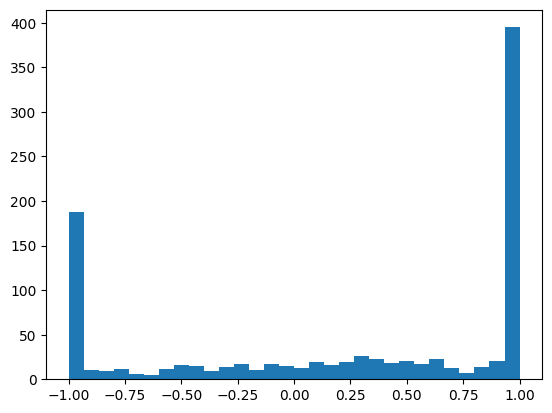

In [7]:
plt.hist(d_h, bins = 30)

(array([186.,   4.,   7.,   9.,   9.,   8.,   9.,  12.,  13.,   5.,   9.,
         19.,  13.,  18.,  17.,  18.,  17.,  27.,  28.,  32.,  14.,  24.,
         18.,  21.,  17.,  18.,  18.,  10.,  12., 388.]),
 array([-1.        , -0.93333333, -0.86666667, -0.8       , -0.73333333,
        -0.66666667, -0.6       , -0.53333333, -0.46666667, -0.4       ,
        -0.33333333, -0.26666667, -0.2       , -0.13333333, -0.06666667,
         0.        ,  0.06666667,  0.13333333,  0.2       ,  0.26666667,
         0.33333333,  0.4       ,  0.46666667,  0.53333333,  0.6       ,
         0.66666667,  0.73333333,  0.8       ,  0.86666667,  0.93333333,
         1.        ]),
 <BarContainer object of 30 artists>)

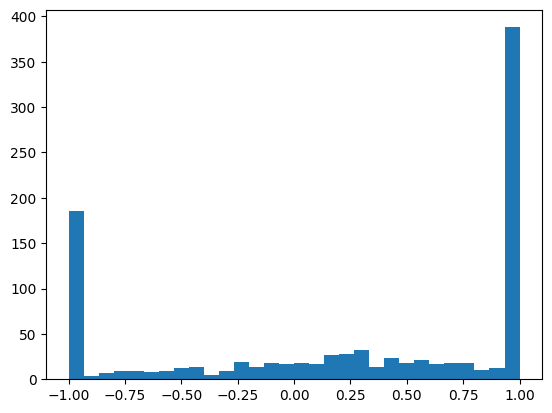

In [8]:
plt.hist(d_l, bins = 30)

## Active link densities

In [2]:
# --- 1. PRE-PROCESSING (Run once per graph) ---
def prepare_graph_numba(G, highest=True, m0=0.0):
    """
    Converts NetworkX graph to Numba-friendly arrays.
    Returns: (adj_indices, adj_offsets, adj_edge_ids, edges_table, 
              reset_state, reset_active_count, reset_active_list, reset_pos_map)
    """
    N = G.number_of_nodes()
    M = G.number_of_edges()
    nodes = list(G.nodes())
    node_map = {n: i for i, n in enumerate(nodes)}
    
    # 1. Edge Indexing: Give every edge a unique ID from 0 to M-1
    edges_list = list(G.edges())
    edge_map_py = {tuple(sorted((node_map[u], node_map[v]))): i for i, (u, v) in enumerate(edges_list)}
    
    # Create lookup table: edge_id -> (u, v)
    edges_table = np.zeros((M, 2), dtype=np.int32)
    for (u, v), idx in edge_map_py.items():
        edges_table[idx] = (u, v)

    # 2. CSR-like Adjacency Construction
    # We store neighbors AND the edge_id connecting them
    adj_indices = []
    adj_edge_ids = []
    adj_offsets = np.zeros(N + 1, dtype=np.int32)
    
    current_offset = 0
    for i in range(N):
        u_node = nodes[i]
        neighbors = list(G[u_node])
        adj_offsets[i] = current_offset
        for v_node in neighbors:
            v = node_map[v_node]
            adj_indices.append(v)
            # Find the edge ID for (u, v)
            edge_key = tuple(sorted((i, v)))
            adj_edge_ids.append(edge_map_py[edge_key])
            current_offset += 1
    adj_offsets[N] = current_offset
    
    adj_indices = np.array(adj_indices, dtype=np.int32)
    adj_edge_ids = np.array(adj_edge_ids, dtype=np.int32)
    
    # 3. Pre-calculate Reset State
    nodes_sorted = sorted(nodes, key=lambda n: G.degree(n), reverse=highest)
    cutoff = int((1 + m0) * N / 2)
    reset_state = np.full(N, -1, dtype=np.int8)
    for i, node in enumerate(nodes_sorted):
        if i < cutoff:
            reset_state[node_map[node]] = 1

    # 4. Pre-calculate Reset Active Edges
    # active_list stores edge_ids
    # pos_map stores the position of an edge_id in active_list (-1 if inactive)
    reset_active_list = np.zeros(M, dtype=np.int32)
    reset_pos_map = np.full(M, -1, dtype=np.int32)
    count = 0
    
    for i in range(M):
        u, v = edges_table[i]
        if reset_state[u] != reset_state[v]:
            reset_active_list[count] = i
            reset_pos_map[i] = count
            count += 1
            
    return (adj_indices, adj_offsets, adj_edge_ids, edges_table, 
            reset_state, count, reset_active_list, reset_pos_map)

# --- 2. NUMBA SIMULATION KERNEL ---
@njit
def run_gillespie_numba(t_max, r, m0, N, M, 
                        adj_indices, adj_offsets, adj_edge_ids, edges_table,
                        reset_state, reset_active_count, reset_active_list, reset_pos_map):
    
    # Initialize State
    states = np.empty(N, dtype=np.int8)
    for i in range(N):
        states[i] = 1 if np.random.random() < (1 + m0) / 2 else -1

    # Initialize Active Edges (Swap-and-Pop Structure)
    active_list = np.zeros(M, dtype=np.int32)  # Stores edge_ids
    pos_map = np.full(M, -1, dtype=np.int32)   # Maps edge_id -> index in active_list
    num_active = 0
    
    # Initial scan to build active list
    for i in range(M):
        u, v = edges_table[i]
        if states[u] != states[v]:
            active_list[num_active] = i
            pos_map[i] = num_active
            num_active += 1
            
    # Output Arrays (Dynamic allocation via chunking or over-allocation)
    # We estimate size to avoid appending; resize if needed.
    capacity = 10000
    times = np.empty(capacity, dtype=np.float64)
    densities = np.empty(capacity, dtype=np.float64)
    
    times[0] = 0.0
    densities[0] = num_active / M
    step_count = 1
    
    tt = 0.0
    
    while tt < t_max:
        w = 2.0 * num_active
        la = w + r
        
        if la == 0:
            break

        dt = -np.log(np.random.random()) / la
        
        if tt + dt > t_max:
            # Record final state at t_max
            if step_count >= capacity:
                capacity *= 2
                new_times = np.empty(capacity, dtype=np.float64)
                new_densities = np.empty(capacity, dtype=np.float64)
                new_times[:step_count] = times[:step_count]
                new_densities[:step_count] = densities[:step_count]
                times, densities = new_times, new_densities
                
            times[step_count] = t_max
            densities[step_count] = densities[step_count-1]
            step_count += 1
            break
            
        tt += dt
        
        # --- EVENT HANDLING ---
        if np.random.random() * la < w:
            # === VOTER FLIP ===
            # 1. Pick random active edge index
            rand_idx = np.random.randint(0, num_active)
            edge_id = active_list[rand_idx]
            
            # 2. Pick node
            u, v = edges_table[edge_id]
            node_to_flip = u if np.random.random() < 0.5 else v
            
            # 3. Flip
            states[node_to_flip] *= -1
            
            # 4. Update Neighbors
            start = adj_offsets[node_to_flip]
            end = adj_offsets[node_to_flip + 1]
            
            for k in range(start, end):
                neighbor = adj_indices[k]
                e_id = adj_edge_ids[k]
                
                # Check status
                is_active = (states[node_to_flip] != states[neighbor])
                current_pos = pos_map[e_id]
                
                if is_active:
                    # Activate if inactive
                    if current_pos == -1:
                        active_list[num_active] = e_id
                        pos_map[e_id] = num_active
                        num_active += 1
                else:
                    # Deactivate if active
                    if current_pos != -1:
                        # Swap with last
                        last_idx = num_active - 1
                        last_edge = active_list[last_idx]
                        
                        active_list[current_pos] = last_edge
                        pos_map[last_edge] = current_pos
                        
                        pos_map[e_id] = -1
                        num_active -= 1
        else:
            # === RESET ===
            # Efficient array copy
            states[:] = reset_state[:]
            active_list[:] = reset_active_list[:]
            pos_map[:] = reset_pos_map[:]
            num_active = reset_active_count
            
        # Record Data
        if step_count >= capacity:
            capacity *= 2
            new_times = np.empty(capacity, dtype=np.float64)
            new_densities = np.empty(capacity, dtype=np.float64)
            new_times[:step_count] = times[:step_count]
            new_densities[:step_count] = densities[:step_count]
            times, densities = new_times, new_densities
            
        times[step_count] = tt
        densities[step_count] = num_active / M
        step_count += 1
        
    return times[:step_count], densities[:step_count]


def get_average_density_numba(G, t_max, r, m0, samples, points=200, highest=True):
    # 1. Prepare static graph arrays (ONCE)
    # This is the only slow Python part, but it runs once for all samples.
    data = prepare_graph_numba(G, highest=highest, m0=m0)
    (adj_indices, adj_offsets, adj_edge_ids, edges_table, 
     reset_state, reset_active_count, reset_active_list, reset_pos_map) = data
    
    N = G.number_of_nodes()
    M = G.number_of_edges()

    # 2. Setup Averaging
    common_time = np.linspace(0, t_max, points)
    density_accumulator = np.zeros(points)
    
    print(f"Running {samples} accelerated simulations...")
    
    for i in range(samples):
        # Numba Call
        t_run, rho_run = run_gillespie_numba(t_max, r, m0, N, M, 
                                             adj_indices, adj_offsets, adj_edge_ids, edges_table,
                                             reset_state, reset_active_count, reset_active_list, reset_pos_map)
        
        # Interpolate
        f_interp = interp1d(t_run, rho_run, kind='previous', 
                            bounds_error=False, fill_value="extrapolate")
        density_accumulator += f_interp(common_time)

    return common_time, density_accumulator / samples

In [5]:
N = 500
s = 5000


# Create Graph
ER = nx.erdos_renyi_graph(n=N, p=0.25) # Larger graph to test speed

# Run Numba Version
t_grid_ER, rho_avg_ER = get_average_density_numba(ER, t_max=6, r=1, m0=0.2, samples=s)
t_grid_low_ER, rho_avg_low_ER = get_average_density_numba(ER, t_max=6, r=1, m0=0.2, samples=s, highest = False)

RG = nx.random_regular_graph(d=5, n=N) # Larger graph to test speed

# Run Numba Version
t_grid_RG, rho_avg_RG = get_average_density_numba(RG, t_max=6, r=1, m0=0.2, samples=s)
t_grid_low_RG, rho_avg_low_RG = get_average_density_numba(RG, t_max=6, r=1, m0=0.2, samples=s, highest = False)

SF = nx.barabasi_albert_graph(n=N, m=3) # Larger graph to test speed

# Run Numba Version
t_grid_SF, rho_avg_SF = get_average_density_numba(SF, t_max=6, r=1, m0=0.2, samples=s)
t_grid_low_SF, rho_avg_low_SF = get_average_density_numba(SF, t_max=6, r=1, m0=0.2, samples=s, highest = False)

Running 5000 accelerated simulations...
Running 5000 accelerated simulations...
Running 5000 accelerated simulations...
Running 5000 accelerated simulations...
Running 5000 accelerated simulations...
Running 5000 accelerated simulations...


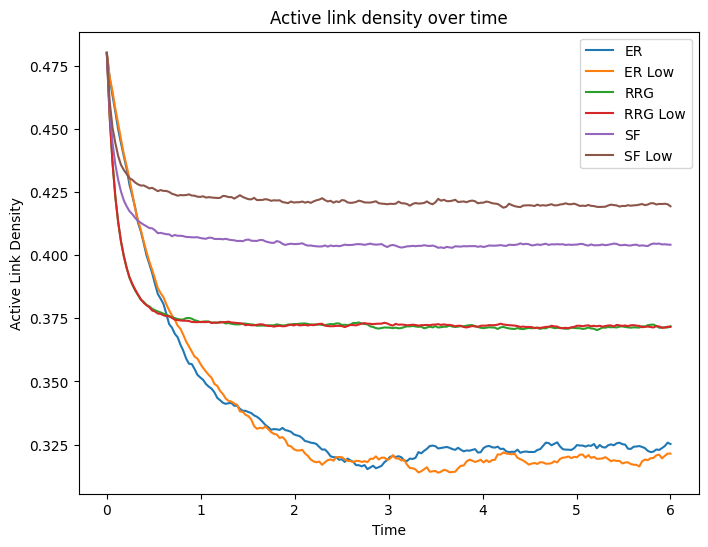

In [6]:
# Plot
plt.figure(figsize=(8, 6))
plt.plot(t_grid_ER, rho_avg_ER, label='ER')
plt.plot(t_grid_low_ER, rho_avg_low_ER, label='ER Low')
plt.plot(t_grid_RG, rho_avg_RG, label='RRG')
plt.plot(t_grid_low_RG, rho_avg_low_RG, label='RRG Low')
plt.plot(t_grid_SF, rho_avg_SF, label='SF')
plt.plot(t_grid_low_SF, rho_avg_low_SF, label='SF Low')
plt.xlabel('Time')
plt.ylabel('Active Link Density')
plt.title('Active link density over time')
plt.legend()
plt.savefig("../figures/complex_stuff.pdf")